In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, ndimage

---
## Tugas 2.2 – Perbandingan Penanganan Batas (Border Handling)


### (a) Pembuatan Citra Sintetis 6×6

Persegi putih 4×4 di tengah latar hitam.


Citra sintetis S:
[[0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0.]]


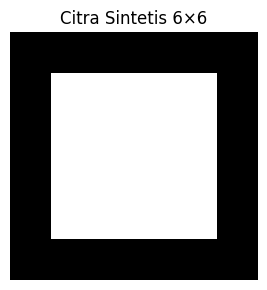

In [2]:
# Buat citra sintetis 6x6
S = np.zeros((6, 6), dtype=float)
S[1:5, 1:5] = 1.0

print("Citra sintetis S:")
print(S)

plt.figure(figsize=(3, 3))
plt.imshow(S, cmap='gray', vmin=0, vmax=1)
plt.title("Citra Sintetis 6×6", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()


### (b) Konvolusi Sobel Vertikal dengan 4 Metode Border Handling


In [3]:
# Kernel Sobel vertikal
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

# 1. Zero Padding — scipy convolve2d mode='same' (default fill=0)
res_zero = signal.convolve2d(S, sobel_x, mode='same', boundary='fill', fillvalue=0)

# 2. Replikasi — ndimage mode='nearest'
res_nearest = ndimage.convolve(S, sobel_x, mode='nearest')

# 3. Refleksi — ndimage mode='mirror'
res_mirror = ndimage.convolve(S, sobel_x, mode='mirror')

# 4. Cropping — scipy convolve2d mode='valid' (output lebih kecil: 4x4)
res_valid = signal.convolve2d(S, sobel_x, mode='valid')

print("Zero Padding (6×6):")
print(res_zero)
print("\nReplikasi / Nearest (6×6):")
print(res_nearest)
print("\nRefleksi / Mirror (6×6):")
print(res_mirror)
print("\nCropping / Valid (4×4):")
print(res_valid)


Zero Padding (6×6):
[[-1. -1.  0.  0.  1.  1.]
 [-3. -3.  0.  0.  3.  3.]
 [-4. -4.  0.  0.  4.  4.]
 [-4. -4.  0.  0.  4.  4.]
 [-3. -3.  0.  0.  3.  3.]
 [-1. -1.  0.  0.  1.  1.]]

Replikasi / Nearest (6×6):
[[-1. -1.  0.  0.  1.  1.]
 [-3. -3.  0.  0.  3.  3.]
 [-4. -4.  0.  0.  4.  4.]
 [-4. -4.  0.  0.  4.  4.]
 [-3. -3.  0.  0.  3.  3.]
 [-1. -1.  0.  0.  1.  1.]]

Refleksi / Mirror (6×6):
[[ 0. -2.  0.  0.  2.  0.]
 [ 0. -3.  0.  0.  3.  0.]
 [ 0. -4.  0.  0.  4.  0.]
 [ 0. -4.  0.  0.  4.  0.]
 [ 0. -3.  0.  0.  3.  0.]
 [ 0. -2.  0.  0.  2.  0.]]

Cropping / Valid (4×4):
[[-3.  0.  0.  3.]
 [-4.  0.  0.  4.]
 [-4.  0.  0.  4.]
 [-3.  0.  0.  3.]]


### (c) Visualisasi Keempat Hasil


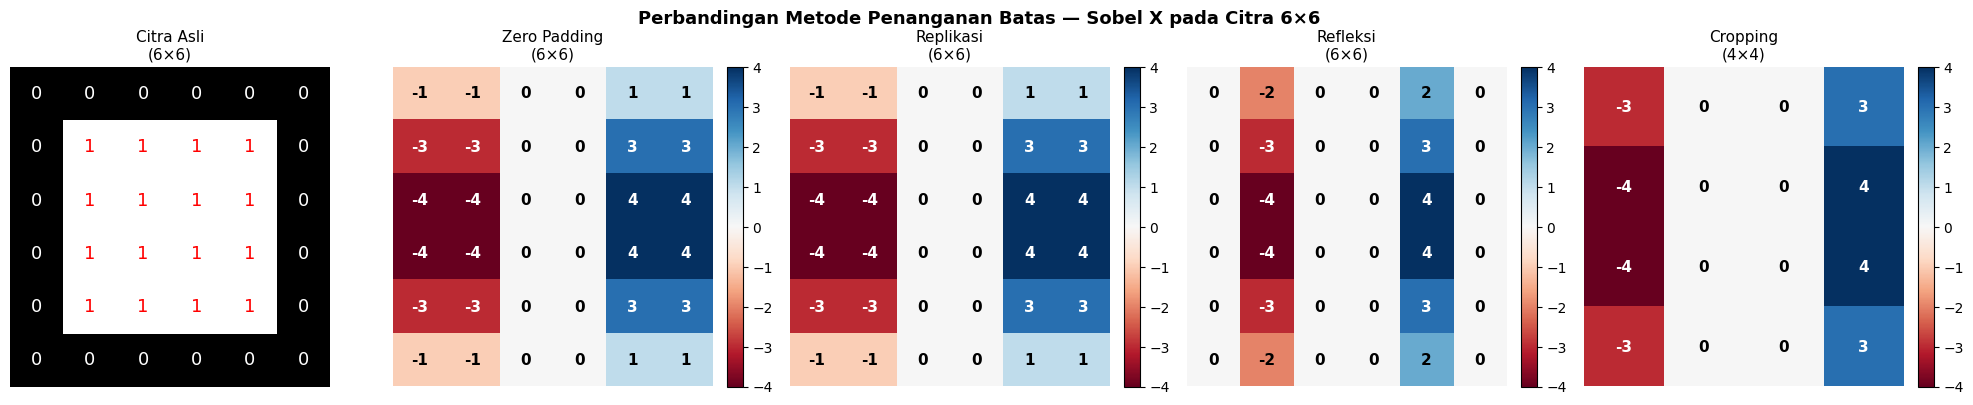

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Perbandingan Metode Penanganan Batas — Sobel X pada Citra 6×6",
             fontsize=13, fontweight='bold')

# Citra asli
axes[0].imshow(S, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Citra Asli\n(6×6)", fontsize=11)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f'{int(S[i,j])}',
                     ha='center', va='center', fontsize=13,
                     color='red' if S[i,j] > 0.5 else 'white')

results = [res_zero, res_nearest, res_mirror, res_valid]
titles  = ["Zero Padding\n(6×6)", "Replikasi\n(6×6)", "Refleksi\n(6×6)", "Cropping\n(4×4)"]

vmax = 4
for ax, res, title in zip(axes[1:], results, titles):
    im = ax.imshow(res, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # ← tambahan ini
    rows, cols = res.shape
    for i in range(rows):
        for j in range(cols):
            ax.text(j, i, f'{res[i,j]:.0f}',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='black' if abs(res[i,j]) < 2.5 else 'white')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig("result_border_comparison.png", dpi=200, bbox_inches='tight')
plt.show()